<a href="https://colab.research.google.com/github/JeanJNMV/leaspy_tutorial/blob/simulation_and_joint_notebook/notebooks/fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
# On Colab the tutorial's own files (tutolib/, content/) are cloned from GitHub.
# BRANCH picks which version students get; set it to "main" once this work is
# merged there. To re-pull after changing it, delete the leaspy_tutorial folder.
BRANCH = "data"
REPO = "https://github.com/aramis-lab/leaspy_tutorial"

import importlib.util, pathlib, subprocess, sys

try:  # find_spec raises (not returns None) when there is no `google` package at all
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
pip = [sys.executable, "-m", "pip", "install", "-q"]

if IN_COLAB:
    if importlib.util.find_spec("leaspy") is None:
        subprocess.run(pip + ["--no-deps",
    "leaspy @ git+https://github.com/aramis-lab/leaspy.git@v2.1.0"], check=True)
        subprocess.run(pip + ["lifelines"], check=True)   # dep Colab may lack
    if not pathlib.Path("leaspy_tutorial").exists():
        subprocess.run(["git", "clone", "-q", "--branch", BRANCH, REPO], check=True)
    ROOT = pathlib.Path("leaspy_tutorial")
else:
    # running from a clone: walk up from the notebook until we find the repo root
    ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
                if (p / "tutolib").is_dir())
sys.path.insert(0, str(ROOT))

import tutolib as tp
print("tutolib", tp.__version__, "loaded from", ROOT)

tutolib 0.1.0 loaded from leaspy_tutorial


In [101]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")



leaspy 2.1.0


# Data

*just load and split the dataset, more details in the data part of the notebook*

In [102]:
df = load_dataset("parkinson")
FEATURES = ["MDS1_total", "SCOPA_total", "MOCA_total"]
SEED = 0
df = df[FEATURES]
print(df.head())

n_subjects = df.index.get_level_values("ID").nunique()
print(f"{n_subjects} subjects in the dataset.")

# Train / test split
df_train = df.loc[:"GS-160"]
df_test = df.loc["GS-161":]
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)
train_ids = df_train.index.unique("ID")
test_ids = df_test.index.unique("ID")
print(f"Train : {len(train_ids)} subjects")
print(f"Test  : {len(test_ids)} subjects")

                  MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768
200 subjects in the dataset.
Train : 160 subjects
Test  : 40 subjects


# Fit

Once we have a dataset that is ready for leaspy, we have to choose which model to fit in our data.

For now the available models are:
- `LogisticModel`
- `LinearModel`
- `JointModel`
- `LogisticMultivariateMixtureModel`

For this example we will run a logistic model. Since we have three scores we will run a multivariate model wo se need to choose beforehand the number of sources.

*Reminder:* The sources represent the groups of scores that evolve in a similar way. It should be a number smaller that the total number of features.

In [103]:
tp.runquestion(4)

In [104]:
# Load the model
model_2_sources = LogisticModel(name="logistic", source_dimension=2)

In [105]:
# Fit the model
model_2_sources.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=50,
        overwrite_logs_folder=True,
    )

|--------------------------------------------------|   0/1000 iterations

/usr/local/lib/python3.12/dist-packages/leaspy/algo/settings.py:86: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/usr/local/lib/python3.12/dist-packages/leaspy/algo/settings.py:167: UserWarning: Overwriting '/content/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 30.40s


In [106]:
# Save the model
model_2_sources.save("_outputs/model_parameters.json")

## Convergence assessment

The model is estimated via an MCMC-SAEM. It is an iterative algorithm that lies in a stochastic approximation. Before interpreting the results of our fit we should check if the model has converged. In simple words we should see if the final estimations are stable and if the chains had explored adequately the parameter space.

During the fit, the value of every estimated parameter is recorded each `save_periodicity` iterations into a `.csv` file under `_outputs/parameter_convergence/`. Those files are what we plot below.

Read the traces from left to right: early on they drift as the algorithm searches, then they should settle into a flat band that only jitters. The dashed line marks the end of the **burn-in** phase, after which leaspy starts averaging, so it is the flatness *to the right of it* that tells you the fit has converged.

In [107]:
PARAMS = ["tau_mean", "tau_std", "xi_std", "noise_std", "g", "v0"]


def plot_convergence(folder, params=PARAMS, features=FEATURES, burn_in=None):
    """Plot one MCMC trace per parameter, straight from the CSVs leaspy saved.
    """
    fig, axes = plt.subplots(3, 2, figsize=(11, 9))
    for ax, name in zip(axes.flat, params):
        trace = pd.read_csv(Path(folder) / f"{name}.csv", index_col=0, header=None)
        if trace.shape[1] == len(features):
            trace.columns = features  # one curve per score, so label them
        trace.plot(ax=ax, lw=1, legend=False)
        end_of_burn_in = burn_in if burn_in is not None else 0.9 * trace.index.max()
        ax.axvline(end_of_burn_in, ls="--", c="0.5")  # end of burn-in
        ax.set_title(name)
        ax.set_xlabel("")

    handles = [plt.Line2D([], [], color=f"C{i}") for i in range(len(features))]
    fig.legend(handles, features, loc="upper center", ncol=len(features), frameon=False)
    fig.supxlabel("iteration")
    fig.tight_layout(rect=(0, 0, 1, 0.96))  # leave a strip at the top for the legend

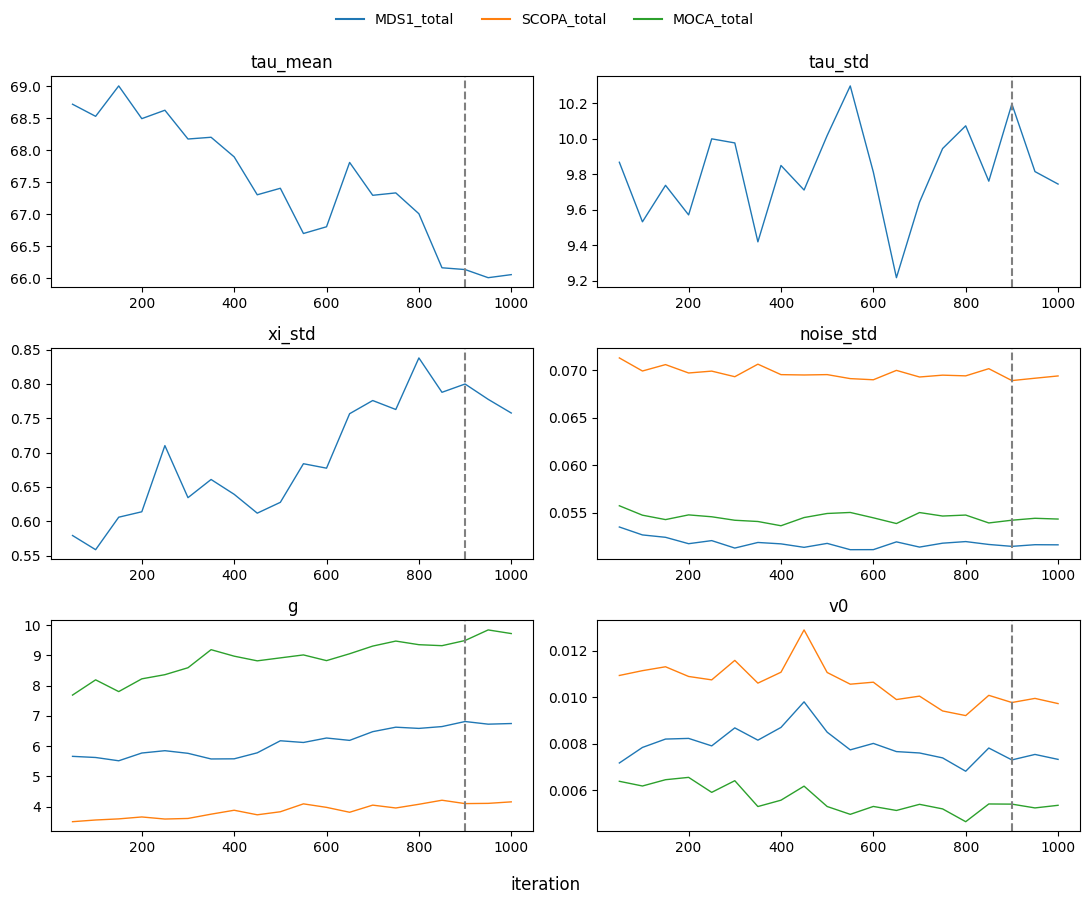

In [108]:
# Your own fit wrote one CSV per parameter into _outputs/parameter_convergence/.
plot_convergence("_outputs/parameter_convergence")
plt.show()

### Question

Take a look at the convergence plots above before answering.

In [109]:
tp.runquestion(3)

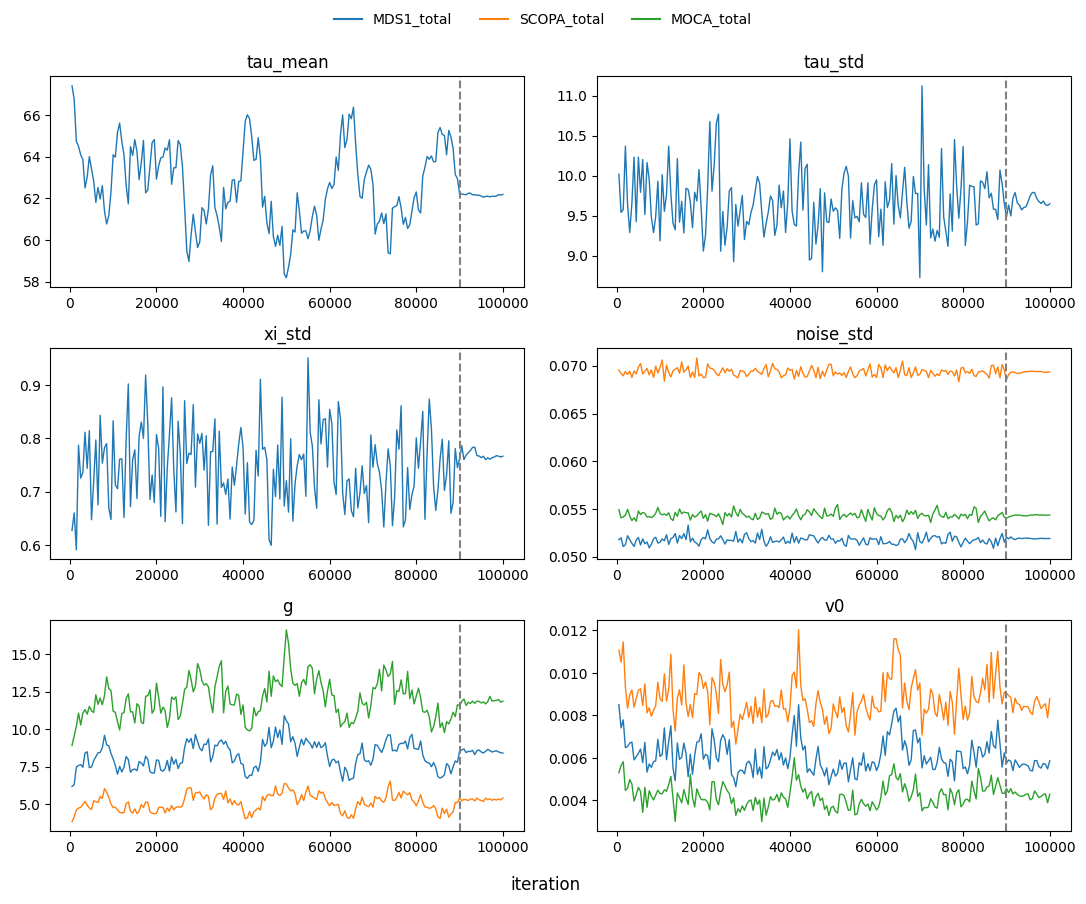

In [110]:
# The canonical 100 000-iteration run shipped with the tutorial
RUN = ROOT / "content" / "reference_run"

plot_convergence(RUN / "parameter_convergence")
plt.show()

**Note:** as shown above, 1000 iterations are not enough for the model to fully converge, so the parameters you just fitted are not the ones you would report in a real analysis.

Rather than draw conclusions from an under-converged fit, we ship the **converged** model: the result of that same 100 000-iteration run, saved to a JSON file. Loading it is instant, so from here on we can look at trustworthy parameters and trajectories without anyone waiting 11 minutes.

In [111]:
# Restoring a saved fit is a one-liner: same class, same API as the model you fitted above
model_100k = LogisticModel.load(str(RUN / "parkinson_fit_V21.json"))

print(type(model_100k).__name__, model_100k.features, f"source_dimension={model_100k.source_dimension}")
# on a loaded model these two are plain dicts, so they are read with [] not a dot
print(f"trained for {model_100k.training_info['n_iter']} iterations "
      f"on {model_100k.dataset_info['n_subjects']} subjects")

LogisticModel ['MDS1_total', 'SCOPA_total', 'MOCA_total'] source_dimension=2
trained for 100000 iterations on 160 subjects


## Model summary

Now that we have a model with a satisfactory convergence, we can look at its fit output via the integrated `summary()` function. Everything from here on reports `model_100k`, the converged fit -- not the 1000-iteration one you trained above.

In [112]:
model_100k.summary()

                                 Model Summary                                  
Model Name: logistic
Model Type: LogisticModel
Features (3): MDS1_total, SCOPA_total, MOCA_total
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5592.5337
Parameters: 19
BIC: -13517.14
AIC: -13575.57

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 100000

Data Context
--------------------------------------------------------------------------------
Subjects: 160
Visits: 1590
Total Observations: 4770
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1
            b0        0.0511    0.0038
            b1       -0.0232    0.0402
                    MDS1_to.  SCOPA_t.  MOCA_to.
  log_g_mean          2.1357    1.6673    2.4747
               

We can show specific elements such as the metrics:

In [113]:
summary = model_100k.summary()
print(f"BIC: {float(summary.bic)}")
print(f"AIC: {float(summary.aic)}")

BIC: -13517.142010010557
AIC: -13575.5703125


Or a specific set of parameters

In [114]:
model_100k.summary().parameters['Individual Parameters']

{'tau_mean': tensor([62.1939]),
 'tau_std': tensor([9.6497]),
 'xi_std': tensor([0.7668])}

## Plotting

We can plot the population trajectories of the converged model with leaspy's internal plotting tool.

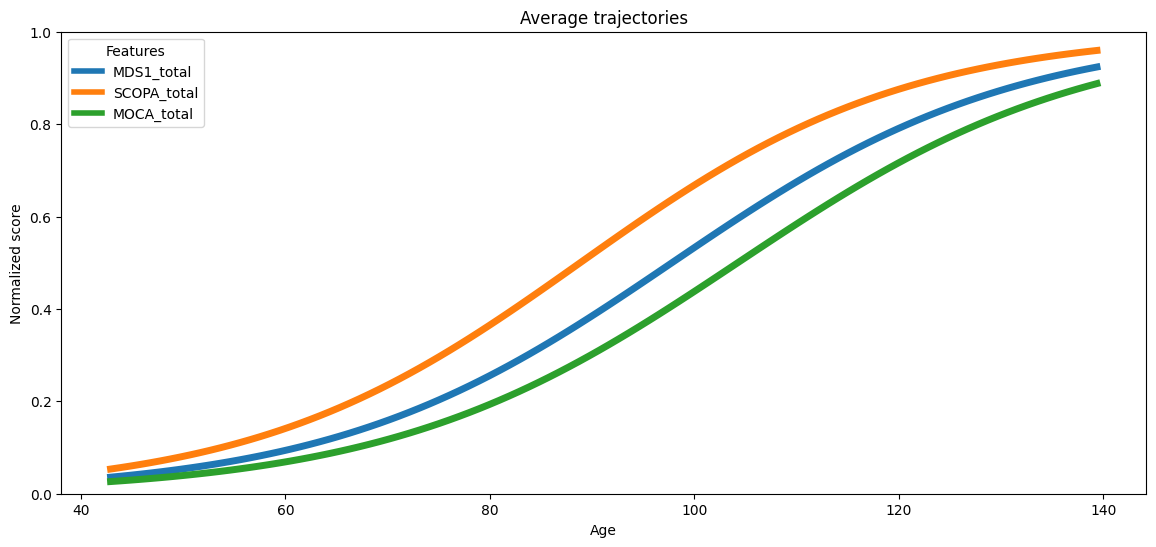

In [115]:
ax = Plotting(model_100k).average_trajectory(
    alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8
)
plt.show()

In [116]:
tp.show_asset("sigmoid_interactive.html")

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Model Comparison

One deliberate exception to what we just said: the exercises below go back to `model_2_sources`, the 1000-iteration fit.

BIC and AIC are only comparable between models trained the same way. Every model you are about to fit runs for 1000 iterations, so ranking them against `model_2_sources` compares the thing we are varying -- the number of sources, then the noise model. Slipping the converged `model_100k` into that ranking would mostly measure how long it trained, and it would win for the wrong reason.

In [117]:
tp.runquestion(5)

### Task 1: Vary the number of sources

Can you load and fit a logistic model with one source and compare it with the previous model?

model_1_source = ...

In [118]:
# If you need help, run this cell to get the code
# Click `Show Solution` to see the answer
tp.solution(1)

In [119]:
# Now compare the two models with their BIC / AIC
tp.solution(2)

### Task 2: Vary the noise model

The default choice is to fit a `gaussian-diagonal` noise, which means that we fit a noise with a separate standard deviation per score


In [120]:
model_2_sources.observation_model_names

['gaussian-diagonal']

Another option is to fit a `gaussian-scalar` noise, which means fitting one global standard deviation for the noise shared between all the scores.

We just have to add the argument `obs_models='gaussian-scalar'` when we load our model.

In [121]:
tp.runquestion(6)

In [122]:
# Fit a 1-source model with a scalar noise
tp.solution(3)

Let's fit also a model with 2 sources and a scalar noise and compare the four models all together.

In [123]:
# Fit a 2-source model with a scalar noise
tp.solution(4)

In [124]:
# Compare the four models with their BIC / AIC
tp.solution(5)

# Simulation

In this section, we will use a fitted Leaspy model to generate a **new synthetic longitudinal cohort**. We will then check whether the parameters used to generate that cohort can be recovered.

## Data and fitted model

We keep the same three Parkinson's disease scores as in the fit practical and reuse `model_100k`, the converged model loaded earlier. This lets us spend our time on simulation rather than fitting again.

In [125]:
print(f"Training cohort: {df_train.index.unique('ID').size} subjects")
print(f"Converged model: {model_100k.dimension} scores, {model_100k.source_dimension} sources")

Training cohort: 160 subjects
Converged model: 3 scores, 2 sources


## The Simulate algorithm

Leaspy generates a cohort in three steps:

1. sample each new subject's individual parameters ($\tau$, $\xi$ and sources) from the fitted population distributions;
2. generate that subject's visit times from a visit design;
3. evaluate the model at those times and add observation noise.

The result therefore resembles the fitted population, but it contains entirely new subjects.

In [126]:
tp.runquestion(7)

## Choose the visit design

With `visit_type="random"`, visit times are controlled by the dictionary below. Times are in years.

| Parameter | Meaning |
| --- | --- |
| `patient_number` | Number of subjects to simulate. |
| `visit_type` | Method used to generate visits; `"random"` samples new schedules. |
| `first_visit_mean` | Mean first-visit offset from each subject's $\tau$. |
| `first_visit_std` | Standard deviation of the first-visit offset. |
| `time_follow_up_mean` | Mean follow-up duration. |
| `time_follow_up_std` | Standard deviation of the follow-up duration. |
| `distance_visit_mean` | Mean time between consecutive visits. |
| `distance_visit_std` | Standard deviation of the time between visits. |
| `min_spacing_between_visits` | Minimum allowed spacing; closer visits are removed. |

Here we request 150 subjects, a mean follow-up of 11 years, and visits every 0.3 years on average (about every 3.6 months). These are deliberately convenient tutorial parameters rather than an attempt to reproduce the constraints of a real cohort. One advantage of simulation is precisely this control over the study design: we can choose the cohort size, follow-up, and visit frequency needed for an experiment.

Random schedules are optional. To use a pre-made set of visit dates, set `visit_type="dataframe"` and provide `df_visits`, a dataframe containing `ID` and `TIME` columns.

In [127]:
visit_parameters = {
    "patient_number": 150,
    "visit_type": "random",
    "first_visit_mean": 0.0,
    "first_visit_std": 0.4,
    "time_follow_up_mean": 11.0,
    "time_follow_up_std": 0.5,
    "distance_visit_mean": 0.3,
    "distance_visit_std": 0.1,
    "min_spacing_between_visits": 1 / 365,
}

visit_parameters

{'patient_number': 150,
 'visit_type': 'random',
 'first_visit_mean': 0.0,
 'first_visit_std': 0.4,
 'time_follow_up_mean': 11.0,
 'time_follow_up_std': 0.5,
 'distance_visit_mean': 0.3,
 'distance_visit_std': 0.1,
 'min_spacing_between_visits': 0.0027397260273972603}

In [128]:
tp.runquestion(8)

### Task: generate the cohort

Call `model_100k.simulate` with the `"simulate"` algorithm, `FEATURES`, `visit_parameters`, and `SEED`. 

In [129]:
# Complete the task in this cell or reveal and run the solution.
# simulated = ...
tp.solution(6)

In [130]:
df_sim = simulated.data.to_dataframe().set_index(["ID", "TIME"])

## Inspect the result

The result contains both the noisy longitudinal observations and the known individual parameters that generated them. Keeping those ground-truth parameters is what makes recovery checks possible.

In [131]:
n_subjects = df_sim.index.unique("ID").size
visits_per_subject = df_sim.groupby(level="ID").size()

print(f"{n_subjects} simulated subjects")
print(f"{len(df_sim)} visits in total")
print(
    f"Visits per subject: median {visits_per_subject.median():.0f} "
    f"(range {visits_per_subject.min()}–{visits_per_subject.max()})"
)
display(df_sim.head())
display(simulated.individual_parameters.head())

150 simulated subjects
5722 visits in total
Visits per subject: median 38 (range 32–45)


MDS1_total  SCOPA_total  MOCA_total
ID TIME                                       
0  60.915    0.092882     0.139483    0.159205
   61.069    0.108419     0.010489    0.074530
   61.301    0.132105     0.146851    0.068910
   61.637    0.227803     0.116858    0.037656
   61.956    0.194354     0.104875    0.104404

,xi,tau,sources_0,sources_1,w_0,w_1,w_2
0,"tensor(1.3526, dtype=torch.float64)","tensor(61.5353, dtype=torch.float64)",-1.248050,-0.862736,0.031678,-0.058731,0.009028
1,"tensor(0.3068, dtype=torch.float64)","tensor(78.7272, dtype=torch.float64)",1.927211,0.893489,-0.035514,0.092562,-0.025358
2,"tensor(0.7504, dtype=torch.float64)","tensor(55.0072, dtype=torch.float64)",0.024732,0.558972,-0.017181,-0.001147,0.013922
3,"tensor(1.7182, dtype=torch.float64)","tensor(54.2189, dtype=torch.float64)",-0.577207,0.386584,-0.009348,-0.030512,0.024618
4,"tensor(1.4320, dtype=torch.float64)","tensor(61.2438, dtype=torch.float64)",0.865012,0.442607,-0.017210,0.041369,-0.010300


### Plot a few simulated trajectories

Subjects differ in disease timing, progression speed and spatial shift, while observation noise adds visit-to-visit variability.

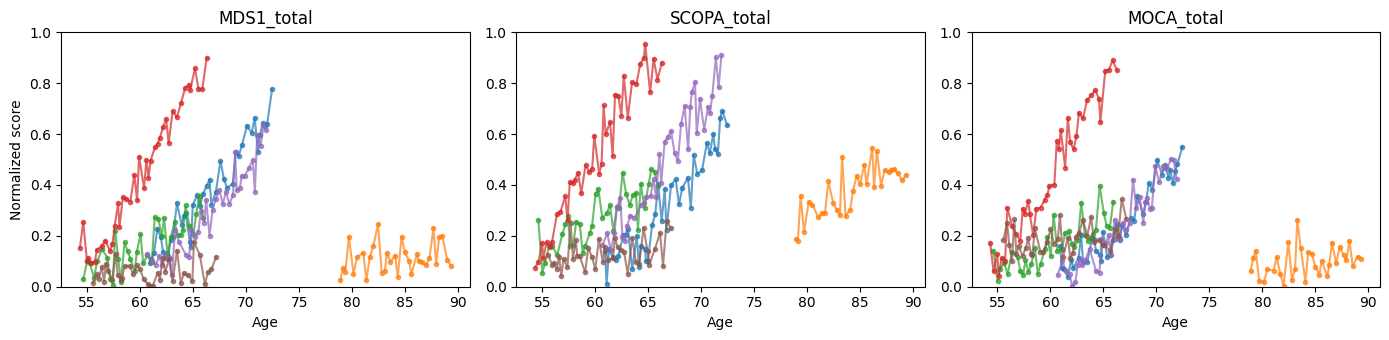

In [132]:
sample_ids = df_sim.index.unique("ID")[:6]
fig, axes = plt.subplots(1, len(FEATURES), figsize=(14, 3.5), sharex=True)

for feature, ax in zip(FEATURES, axes):
    for subject_id in sample_ids:
        subject = df_sim.loc[subject_id]
        ax.plot(subject.index, subject[feature], marker="o", ms=3, alpha=0.7)
    ax.set_title(feature)
    ax.set_xlabel("Age")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Normalized score")
plt.tight_layout()
plt.show()

## Simulation quality assessment

A visual check is useful but not sufficient. We now follow a short recovery pipeline to assess whether the simulated cohort is consistent with the fitted model:

1. **fit the same model family** to the simulated observations;
2. **compare the refitted population** parameters with the generating parameters;
3. **personalize the simulated subjects and compare** their estimated $\tau$, $\xi$ and space shifts with the known values.

This is an **illustrative recovery check**, not a formal guarantee: finite samples and a short stochastic fit prevent exact equality.

### Refit on the simulated cohort

In [133]:
SIM_MODEL_PATH = RUN / "parkinson_simulation_fit_V21.json"

if SIM_MODEL_PATH.exists():
    sim_model = LogisticModel.load(str(SIM_MODEL_PATH))
    print("Cached simulation model loaded.")
else:
    sim_model = LogisticModel(name="logistic", source_dimension=2)
    sim_model.fit(
        df_sim,
        "mcmc_saem",
        seed=SEED,
        n_iter=10000,
        progress_bar=True,
    )
    sim_model.save(str(SIM_MODEL_PATH))
    print("Simulation model fitted and saved.")

Cached simulation model loaded.


### Population-level parameter recovery

In [134]:
rows = []
for parameter in [
    "tau_mean", "tau_std", "xi_std", "noise_std", "log_g_mean", "log_v0_mean"
]:
    generating = model_100k.parameters[parameter].detach().cpu().numpy().ravel()
    refitted = sim_model.parameters[parameter].detach().cpu().numpy().ravel()

    # Report g and v0 on their interpretable (non-logarithmic) scale.
    if parameter in {"log_g_mean", "log_v0_mean"}:
        generating, refitted = np.exp(generating), np.exp(refitted)

    label = {"log_g_mean": "g", "log_v0_mean": "v0"}.get(parameter, parameter)
    features = FEATURES if len(generating) == len(FEATURES) else [""] * len(generating)

    for feature, true_value, estimated_value in zip(features, generating, refitted):
        relative_error = (estimated_value - true_value) / abs(true_value) * 100
        rows.append({
            "Parameter": label,
            "Feature": feature,
            "Generating": round(float(true_value), 4),
            "Refitted": round(float(estimated_value), 4),
            "Relative error (%)": round(float(relative_error), 1),
        })

population_recovery = pd.DataFrame(rows)
display(population_recovery)

,Parameter,Feature,Generating,Refitted,Relative error (%)
0,tau_mean,,62.1939,61.2935,-1.4
1,tau_std,,9.6497,8.7817,-9.0
2,xi_std,,0.7668,0.8537,11.3
3,noise_std,MDS1_total,0.0519,0.0512,-1.3
4,noise_std,SCOPA_total,0.0694,0.0700,0.8
5,noise_std,MOCA_total,0.0544,0.0537,-1.2
6,g,MDS1_total,8.4634,8.0748,-4.6
7,g,SCOPA_total,5.2976,5.0824,-4.1
8,g,MOCA_total,11.8787,11.9513,0.6
9,v0,MDS1_total,0.0057,0.0061,8.4


Read this table parameter by parameter. With the fixed seed, the location and noise parameters are recovered closely, while the spread of progression speeds (`xi_std`) is less stable. That discrepancy is useful information: a larger cohort or a longer refit would be needed before claiming precise recovery of every population parameter.

### Individual-level parameter recovery

We compare disease timing $\tau_i$, log-speed $\xi_i$ and the feature-specific space shifts $w_{ik}$. Estimated shifts are reconstructed from the personalized sources and the refitted mixing matrix.

In [135]:
# ICC measures agreement between true and estimated values (1 is perfect)
def icc(x, y):
    values = np.column_stack([x, y])
    subject_means = values.mean(axis=1)
    ms_between = 2 * ((subject_means - values.mean()) ** 2).sum() / (len(x) - 1)
    ms_error = ((values - subject_means[:, None]) ** 2).sum() / len(x)
    return (ms_between - ms_error) / (ms_between + ms_error)

In [136]:
# Ground truth and personalized estimates
ip_est = sim_model.personalize(
    df_sim, "scipy_minimize", seed=SEED, progress_bar=True
).to_dataframe().astype(float)
ip_true = simulated.individual_parameters.loc[ip_est.index].astype(float)

# Reconstruct feature-specific shifts from the latent sources
shift_columns = [f"w_{i}" for i in range(len(FEATURES))]
ip_est[shift_columns] = (
    ip_est.filter(regex=r"^sources_").to_numpy()
    @ sim_model.state.get_tensor_value("mixing_matrix").cpu().numpy()
)

parameters = [("tau", r"$\tau_i$", ""), ("xi", r"$\xi_i$", "")] + [
    (f"w_{k}", rf"$w_{{i,{k}}}$", feature)
    for k, feature in enumerate(FEATURES)
]
metrics = []

for parameter, _, feature in parameters:
    true_values, estimated_values = ip_true[parameter], ip_est[parameter]
    metrics.append({
        "Parameter": "w" if parameter.startswith("w_") else parameter,
        "Feature": feature,
        "ICC(3,1)": round(float(icc(true_values, estimated_values)), 3),
        "Pearson r": round(float(true_values.corr(estimated_values)), 3),
    })

individual_recovery = pd.DataFrame(metrics)
display(individual_recovery)

|##################################################|   150/150 subjects

Personalize with `AlgorithmName.PERSONALIZE_SCIPY_MINIMIZE` took: 1m 40.44s


,Parameter,Feature,"ICC(3,1)",Pearson r
0,tau,,0.978,0.979
1,xi,,0.936,0.938
2,w,MDS1_total,0.980,0.983
3,w,SCOPA_total,0.986,0.986
4,w,MOCA_total,0.988,0.990


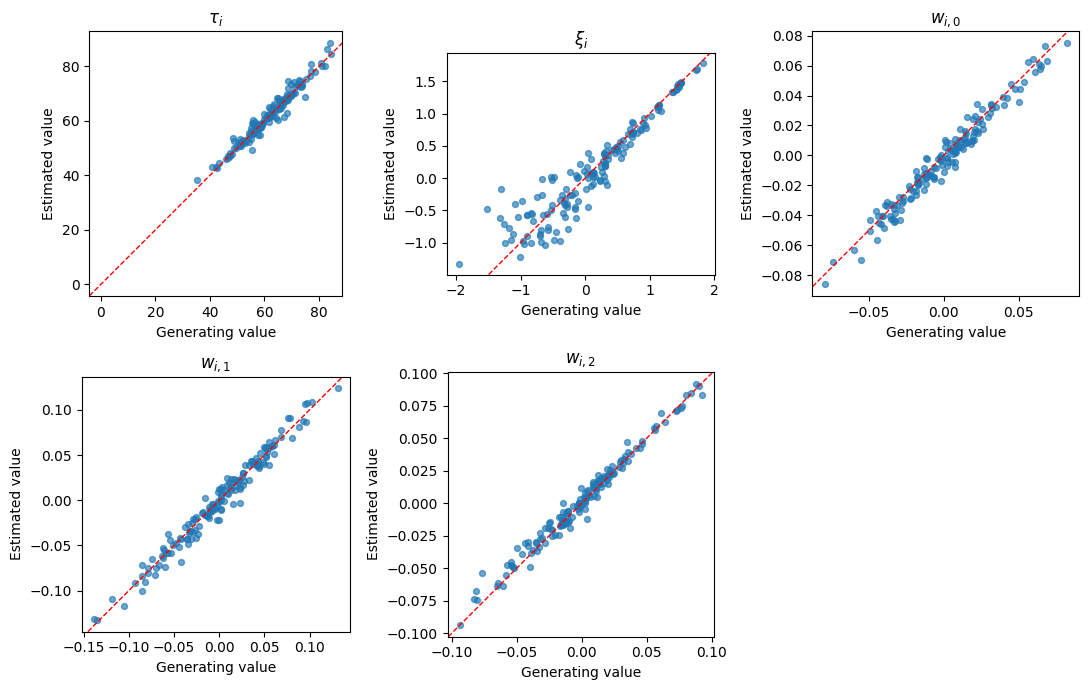

In [137]:
_, axes = plt.subplots(2, 3, figsize=(11, 7))

for ax, (parameter, title, _) in zip(axes.ravel(), parameters):
    true_values, estimated_values = ip_true[parameter], ip_est[parameter]
    ax.scatter(true_values, estimated_values, s=18, alpha=0.65)
    ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
    ax.set(title=title, xlabel="Generating value", ylabel="Estimated value", aspect="equal")

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

In [138]:
tp.runquestion(9)

# Extension: Joint model

In this extension, we will fit a model that combines **longitudinal trajectories** with a **time-to-event outcome**. We will inspect the same calibration outputs as in the logistic fit practical, while highlighting exactly what the joint model adds.

## Joint longitudinal and survival data

We use the synthetic ALS joint dataset shipped with this workshop. It contains four normalized longitudinal outcomes and one event endpoint.

In addition to `ID`, `TIME`, and the longitudinal features, a joint dataframe needs:

| Column | Meaning |
| --- | --- |
| `EVENT_TIME` | Observed event time, or censoring time if the event was not observed. |
| `EVENT_BOOL` | `1` for an observed event and `0` for right censoring. |

Right censoring does **not** mean that the subject never experiences the event; it means that the event status is unknown after `EVENT_TIME`.

In [139]:
from leaspy.models import JointModel

In [140]:
DATA = ROOT / "content" / "data"

FEATURES = [
    "ALSFRS_R_BULBAR",
    "ALSFRS_R_FINE_MOTOR",
    "ALSFRS_R_GROSS_MOTOR",
    "ALSFRS_R_TOTAL",
]
SEED = 0

# Load the workshop data from the tutorial repository.
df_joint = (
    pd.read_csv(
        DATA / "simulated_data_for_joint_model.csv",
        dtype={"ID": str},
    )
    .set_index(["ID", "TIME"])
    .sort_index()
)

print(f"{df_joint.index.unique('ID').size} subjects, {len(df_joint)} visits")
display(df_joint.head())

150 subjects, 1022 visits


EVENT_TIME  EVENT_BOOL  ALSFRS_R_BULBAR  ALSFRS_R_FINE_MOTOR  \
ID  TIME                                                                   
000 33.233   40.645361           1     7.520784e-14             0.000000   
    34.276   40.645361           1     1.560653e-01             0.025897   
    35.406   40.645361           1     1.077552e-01             0.183508   
    36.551   40.645361           1     6.151454e-01             0.799267   
    37.610   40.645361           1     8.053792e-01             1.000000   

            ALSFRS_R_GROSS_MOTOR  ALSFRS_R_TOTAL  
ID  TIME                                          
000 33.233         7.714040e-122        0.000143  
    34.276          2.865906e-05        0.107026  
    35.406          2.292672e-01        0.225380  
    36.551          7.012614e-01        0.574041  
    37.610          9.482336e-01        0.792261

In [141]:
tp.runquestion(10)

### One event record per subject

The dataframe remains visit-level, so the subject-level `EVENT_TIME` and `EVENT_BOOL` values are repeated on every visit row. For each subject, both columns must be constant.

In [142]:
event_table = df_joint.groupby(level="ID")[["EVENT_TIME", "EVENT_BOOL"]].first()
event_counts = event_table["EVENT_BOOL"].value_counts().sort_index()

print(f"Observed events: {event_counts.get(1, 0)}")
print(f"Right-censored subjects: {event_counts.get(0, 0)}")
display(event_table.head())

Observed events: 103
Right-censored subjects: 47


,EVENT_TIME,EVENT_BOOL
ID,,
000,40.645361,1
001,63.944898,0
002,49.224329,1
003,56.175099,0
004,46.270729,1


In [143]:
tp.runquestion(11)

### Task: create joint Leaspy data

Convert `df_joint` with `Data.from_dataframe`. Unlike an ordinary longitudinal dataset, the `data_type` must explicitly be `"joint"` so Leaspy separates the repeated measurements from the event outcome.

In [144]:
# Complete the task in this cell or reveal and run the solution.
# data_joint = ...
tp.solution(7)

## Fit the joint model

Leaspy's joint model couples:

1. the same logistic longitudinal submodel used in the fit practical;
2. a Weibull survival submodel for the event.

Both processes share each subject's latent disease age through $\tau_i$ and $\xi_i$. With multiple longitudinal outcomes, the sources also affect event risk through coefficients $\zeta$.

Here `nb_events=1` because `EVENT_BOOL` contains only 0 and 1, and we use two sources as in the multivariate logistic example.

In [145]:
JOINT_MODEL_PATH = RUN / "als_joint_model.json"

if JOINT_MODEL_PATH.exists():
    model = JointModel.load(str(JOINT_MODEL_PATH))
    print("Cached joint model loaded.")
else:
    model = JointModel(
        name="joint",
        nb_events=1,
        source_dimension=2,
    )
    model.fit(
        data_joint,
        "mcmc_saem",
        seed=SEED,
        n_iter=100000,
        progress_bar=True,
    )
    model.save(str(JOINT_MODEL_PATH))
    print("Joint model fitted and saved.")

Cached joint model loaded.


## What changes compared with a logistic fit?

The joint model retains every longitudinal component of the logistic model and adds an event likelihood.

| Fit output | Logistic model | Joint model |
| --- | --- | --- |
| Longitudinal observation model | Gaussian | Same Gaussian model |
| Event observation model | None | Right-censored Weibull |
| Longitudinal population parameters | $g$, $v_0$, betas, noise | Same parameters |
| Individual-parameter distributions | $\tau$, $\xi$, sources | Same shared parameters |
| Survival-specific parameters | None | $\nu$, $\rho$, and $\zeta$ |
| Likelihood and information criteria | Longitudinal observations only | Longitudinal **and** event observations |

Because the likelihoods do not contain the same outcomes, the joint model's BIC/AIC should not be directly ranked against those from the longitudinal-only fit.

## Model summary

In [146]:
summary = model.summary()
print(summary)

                                 Model Summary                                  
Model Name: joint
Model Type: JointModel
Features (4): ALSFRS_R_BULBAR, ALSFRS_R_FINE_MOTOR, ALSFRS_R_GROSS_MOTOR,
    ALSFRS_R_TOTAL
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal, weibull-right-censored-with-sources
Neg. Log-Likelihood: -3974.4367
Parameters: 24
BIC: -10193.91
AIC: -10266.16

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 100000

Data Context
--------------------------------------------------------------------------------
Subjects: 150
Visits: 1022
Total Observations: 4088
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  log_rho_mean       [0.4182]
  n_log_nu_mean      [-1.5781]
  betas_mean:
                          s0        s1
            b0       -0.2289   -0.1002
            b1   

### Metrics

The API is unchanged, but the negative log-likelihood, BIC, and AIC now summarize the **joint** longitudinal-event likelihood. The number of observed events is also part of the fitted model's data context.

In [147]:
fit_metrics = pd.Series({
    "Negative log-likelihood": float(summary.nll),
    "Number of parameters": int(summary.n_total_params),
    "BIC": float(summary.bic),
    "AIC": float(summary.aic),
    "Observed events": int(model.dataset_info["n_events"]),
}, name="Joint fit")

display(fit_metrics.to_frame().round(2))

,Joint fit
Negative log-likelihood,-3974.44
Number of parameters,24.00
BIC,-10193.91
AIC,-10266.16
Observed events,103.00


### Shared individual-parameter distributions

The familiar $\tau$ and $\xi$ distributions, together with the sources, still describe inter-individual variability. 

In the joint model, these latent variables are shared with the survival process rather than being learned from longitudinal scores alone. The implementation also displays `zeta_mean` in this section: unlike $\tau$ and $\xi$, it is a joint-specific population coefficient linking the sources to event risk.

In [148]:
summary.parameters["Individual Parameters"]

{'tau_mean': tensor([55.2530]),
 'tau_std': tensor([11.6956]),
 'xi_std': tensor([1.1317]),
 'zeta_mean': tensor([[0.0591],
         [0.0175]])}

### Survival-specific population parameters

The joint model adds:

- $\nu$: Weibull scale;
- $\rho$: Weibull shape;
- $\zeta$: effect of each source on the event hazard.

Leaspy stores $-\log(\nu)$ and $\log(\rho)$ internally, so we transform them back to their interpretable scales below. These rows have no equivalent in a logistic-only fit.

In [149]:
nu = np.exp(-model.parameters["n_log_nu_mean"].detach().cpu().numpy())
rho = np.exp(model.parameters["log_rho_mean"].detach().cpu().numpy())
zeta = model.parameters["zeta_mean"].detach().cpu().numpy().ravel()

survival_summary = pd.DataFrame({
    "Parameter": ["nu (scale)", "rho (shape)"]
    + [f"zeta, source {i}" for i in range(len(zeta))],
    "Estimate": np.concatenate([nu, rho, zeta]),
})
display(survival_summary.round(3))

,Parameter,Estimate
0,nu (scale),4.846
1,rho (shape),1.519
2,"zeta, source 0",0.059
3,"zeta, source 1",0.017


In [150]:
tp.runquestion(12)

## Simulation with the Joint model

`simulate` is not yet available for the joint model, but it will arrive very soon with **Leaspy v2.2**.